# 05_feature_selection_validation.ipynb

Question this notebook answers:
"Do the 11 features selected in Notebook 04 perform nearly as well as all 17?"

Pre-committed success criteria (decided BEFORE seeing results):
Feature selection is validated as successful if F1-score drops by LESS
THAN 2% compared to Notebook 03's 17-feature baseline. A smaller,
near-equal-performing feature set is more interpretable and clinically
deployable, so a small drop is an acceptable, expected tradeoff — not a failure.

Same train/test split as Notebook 03 (same random_state=42), just
column-reduced to 11 features. This keeps the comparison fair.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)
!pip install xgboost -q
import joblib
import warnings
warnings.filterwarnings("ignore")
plt.style.use("ggplot")

In [7]:
from google.colab import files
uploaded = files.upload()
# Upload these 5 files:
# X_train_binary.csv, X_test_binary.csv, y_train_binary.csv, y_test_binary.csv
# 4_selected_features.csv

X_train_full = pd.read_csv("X_train_binary.csv")
X_test_full = pd.read_csv("X_test_binary.csv")
y_train = pd.read_csv("y_train_binary.csv").squeeze()
y_test = pd.read_csv("y_test_binary.csv").squeeze()

print("Full feature set shape:", X_train_full.shape, X_test_full.shape)

Saving X_test_binary.csv to X_test_binary (1).csv
Saving X_train_binary.csv to X_train_binary (1).csv
Saving y_test_binary.csv to y_test_binary (1).csv
Saving y_train_binary.csv to y_train_binary (1).csv
Full feature set shape: (736, 17) (184, 17)


In [10]:
from google.colab import files
uploaded = files.upload()
selected_df = pd.read_csv("04_selected_features.csv")
selected_features = selected_df["Feature"].tolist()

print(selected_features)
print(f"\nTotal Selected Features: {len(selected_features)}")

Saving 04_selected_features.csv to 04_selected_features (2).csv
['cp', 'exang', 'ca', 'sex', 'chol_missing', 'slope_missing', 'thal', 'thalach', 'age', 'oldpeak', 'fbs']

Total Selected Features: 11


In [12]:
X_train_reduced = X_train_full[selected_features].copy()
X_test_reduced = X_test_full[selected_features].copy()

print("Reduced feature set shape:", X_train_reduced.shape, X_test_reduced.shape)

Reduced feature set shape: (736, 11) (184, 11)


In [13]:
results_reduced = {}

def evaluate_model(model, X_test, y_test, model_name):
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    results_reduced[model_name] = {
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4)
    }

    print(f"\n{'='*50}")
    print(model_name)
    print('='*50)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print("\nClassification Report\n")
    print(classification_report(y_test, predictions))

    # Updated plot aesthetics to match ggplot style seamlessly
    ConfusionMatrixDisplay.from_predictions(y_test, predictions, cmap="Greens")
    plt.title(f"{model_name} ({len(selected_features)} Features)")
    plt.grid(False) # Turn off background grid lines for the confusion matrix display
    plt.show()


Logistic Regression
Accuracy : 0.8261
Precision: 0.8302
Recall   : 0.8627
F1 Score : 0.8462

Classification Report

              precision    recall  f1-score   support

           0       0.82      0.78      0.80        82
           1       0.83      0.86      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184



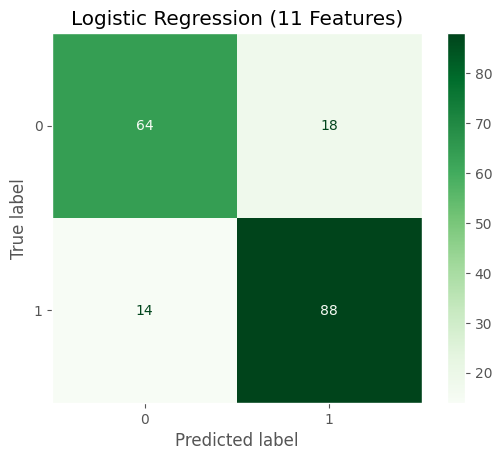

['05_logistic_regression.pkl']

In [14]:
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_reduced, y_train)

evaluate_model(logistic_model, X_test_reduced, y_test, "Logistic Regression")
joblib.dump(logistic_model, "05_logistic_regression.pkl")


Random Forest
Accuracy : 0.8478
Precision: 0.8364
Recall   : 0.9020
F1 Score : 0.8679

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.78      0.82        82
           1       0.84      0.90      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184



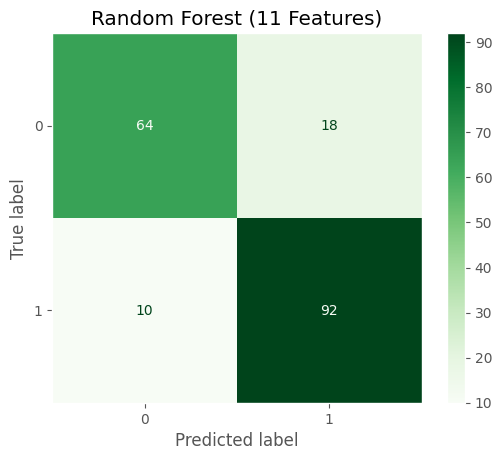

['05_random_forest.pkl']

In [15]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_reduced, y_train)

evaluate_model(rf_model, X_test_reduced, y_test, "Random Forest")
joblib.dump(rf_model, "05_random_forest.pkl")


SVM
Accuracy : 0.7011
Precision: 0.6942
Recall   : 0.8235
F1 Score : 0.7534

Classification Report

              precision    recall  f1-score   support

           0       0.71      0.55      0.62        82
           1       0.69      0.82      0.75       102

    accuracy                           0.70       184
   macro avg       0.70      0.69      0.69       184
weighted avg       0.70      0.70      0.69       184



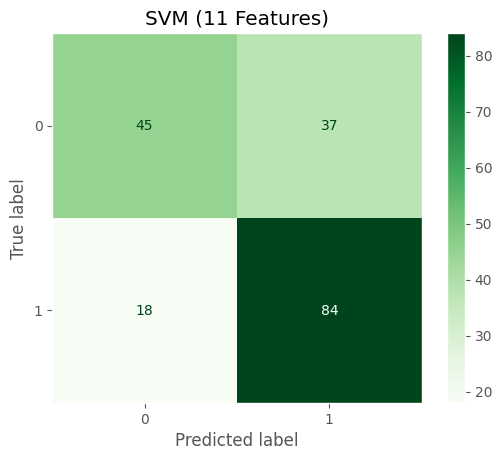

['05_svm.pkl']

In [16]:
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_model.fit(X_train_reduced, y_train)

evaluate_model(svm_model, X_test_reduced, y_test, "SVM")
joblib.dump(svm_model, "05_svm.pkl")


XGBoost
Accuracy : 0.8315
Precision: 0.8381
Recall   : 0.8627
F1 Score : 0.8502

Classification Report

              precision    recall  f1-score   support

           0       0.82      0.79      0.81        82
           1       0.84      0.86      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



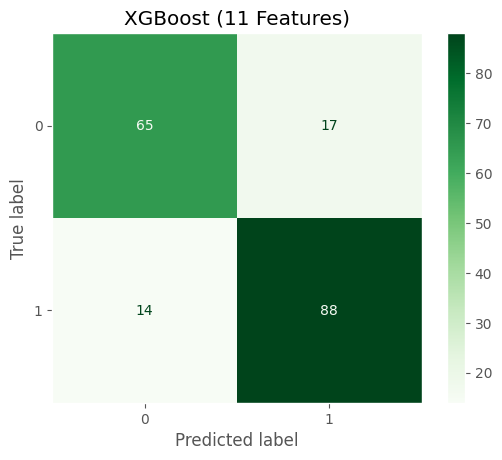

['05_xgboost.pkl']

In [17]:
xgb_model = XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    random_state=42, eval_metric="logloss"
)
xgb_model.fit(X_train_reduced, y_train)

evaluate_model(xgb_model, X_test_reduced, y_test, "XGBoost")
joblib.dump(xgb_model, "05_xgboost.pkl")

In [18]:
comparison_reduced = pd.DataFrame(results_reduced).T
comparison_reduced = comparison_reduced.sort_values(by="Accuracy", ascending=False)
comparison_reduced

,Accuracy,Precision,Recall,F1 Score
Random Forest,0.8478,0.8364,0.9020,0.8679
XGBoost,0.8315,0.8381,0.8627,0.8502
Logistic Regression,0.8261,0.8302,0.8627,0.8462
SVM,0.7011,0.6942,0.8235,0.7534


In [19]:
# Notebook 03's baseline results
baseline_17_features = {
    "Logistic Regression": {"Accuracy": 0.8043, "Precision": 0.8300, "Recall": 0.8137, "F1 Score": 0.8218},
    "Random Forest":       {"Accuracy": 0.8370, "Precision": 0.8462, "Recall": 0.8627, "F1 Score": 0.8544},
    "SVM":                 {"Accuracy": 0.7120, "Precision": 0.7094, "Recall": 0.8137, "F1 Score": 0.7580},
    "XGBoost":              {"Accuracy": 0.8315, "Precision": 0.8318, "Recall": 0.8725, "F1 Score": 0.8517}
}

baseline_df = pd.DataFrame(baseline_17_features).T
baseline_df.columns = [f"{c} (17-feat)" for c in baseline_df.columns]

reduced_df = comparison_reduced.copy()
reduced_df.columns = [f"{c} ({len(selected_features)}-feat)" for c in reduced_df.columns]

delta_table = baseline_df.join(reduced_df)

# Computing the actual deltas
delta_table[f"Δ Accuracy"] = (delta_table[f"Accuracy ({len(selected_features)}-feat)"] - delta_table["Accuracy (17-feat)"]).round(4)
delta_table["Δ F1 Score"] = (delta_table[f"F1 Score ({len(selected_features)}-feat)"] - delta_table["F1 Score (17-feat)"]).round(4)

# Validation rule application
delta_table["Validated (F1 drop < 2%)"] = delta_table["Δ F1 Score"] >= -0.02

print(delta_table[[
    "Accuracy (17-feat)", f"Accuracy ({len(selected_features)}-feat)", "Δ Accuracy",
    "F1 Score (17-feat)", f"F1 Score ({len(selected_features)}-feat)", "Δ F1 Score",
    "Validated (F1 drop < 2%)"
]])

                     Accuracy (17-feat)  Accuracy (11-feat)  Δ Accuracy  \
Logistic Regression              0.8043              0.8261      0.0218   
Random Forest                    0.8370              0.8478      0.0108   
SVM                              0.7120              0.7011     -0.0109   
XGBoost                          0.8315              0.8315      0.0000   

                     F1 Score (17-feat)  F1 Score (11-feat)  Δ F1 Score  \
Logistic Regression              0.8218              0.8462      0.0244   
Random Forest                    0.8544              0.8679      0.0135   
SVM                              0.7580              0.7534     -0.0046   
XGBoost                          0.8517              0.8502     -0.0015   

                     Validated (F1 drop < 2%)  
Logistic Regression                      True  
Random Forest                            True  
SVM                                      True  
XGBoost                                  True  


In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cross_validate_model(model, X, y):
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    return scores.mean(), scores.std(), scores

cv_results_reduced = {}

models_reduced = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4,
                             random_state=42, eval_metric="logloss")
}

for name, model in models_reduced.items():
    mean_acc, std_acc, scores = cross_validate_model(model, X_train_reduced, y_train)
    cv_results_reduced[name] = {"Mean Accuracy": round(mean_acc, 4), "Std Dev": round(std_acc, 4)}
    print(f"{name}: Mean={mean_acc:.4f}, Std={std_acc:.4f}")

cv_df_reduced = pd.DataFrame(cv_results_reduced).T.sort_values(by="Mean Accuracy", ascending=False)
cv_df_reduced

Logistic Regression: Mean=0.8167, Std=0.0395
Random Forest: Mean=0.7922, Std=0.0394
SVM: Mean=0.6820, Std=0.0516
XGBoost: Mean=0.7827, Std=0.0390


,Mean Accuracy,Std Dev
Logistic Regression,0.8167,0.0395
Random Forest,0.7922,0.0394
XGBoost,0.7827,0.0390
SVM,0.6820,0.0516


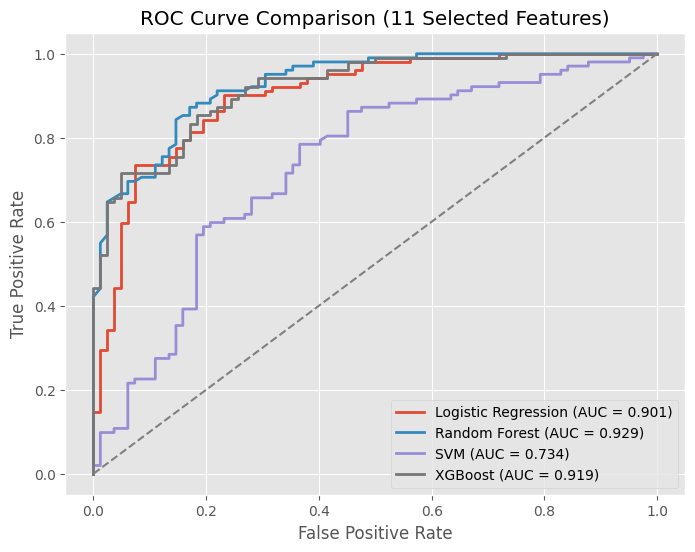

In [21]:
roc_models_reduced = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4,
                             random_state=42, eval_metric="logloss")
}

for model in roc_models_reduced.values():
    model.fit(X_train_reduced, y_train)

plt.figure(figsize=(8, 6))
for name, model in roc_models_reduced.items():
    probs = model.predict_proba(X_test_reduced)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve Comparison ({len(selected_features)} Selected Features)")
plt.legend()
plt.grid(True)
plt.savefig("05_roc_curve.png", dpi=150)
plt.show()

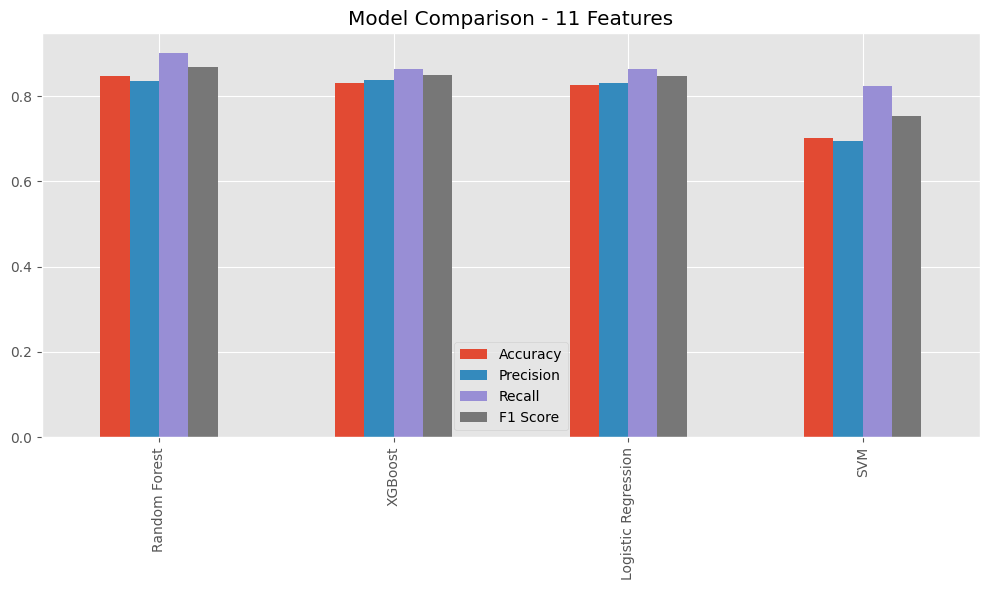

All outputs saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
comparison_reduced.to_csv("05_model_comparison.csv", index=True)
delta_table.to_csv("05_validation_results.csv", index=True)
cv_df_reduced.to_csv("05_cv_results.csv", index=True)

comparison_reduced.plot(kind="bar", figsize=(10, 6), title=f"Model Comparison - {len(selected_features)} Features")
plt.tight_layout()
plt.savefig("05_validation_comparison.png", dpi=150)
plt.show()

print("All outputs saved.")

from google.colab import files

files_to_download = [
    "05_model_comparison.csv", "05_validation_results.csv", "05_cv_results.csv",
    "05_validation_comparison.png", "05_roc_curve.png",
    "05_logistic_regression.pkl", "05_random_forest.pkl", "05_svm.pkl", "05_xgboost.pkl"
]

for f in files_to_download:
    files.download(f)